# 7 Multiple Linear Regression
### MULTIPLE LINEAR REGRESSION
By **Mohan Sirumalla**
***


## Assignment Task:
Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.\
**Dataset Description:**\
<p><strong>The dataset consists of the following variables</strong></p>


|Name |Description|
|-------|-----|
|Age|Age in years|
|KM| Accumulated Kilometers on odometer|
|FuelType| Fuel Type (Petrol, Diesel, CNG)|
|HP| Horse Power|
|Automatic| Automatic ( (Yes=1, No=0)|
|CC| Cylinder Volume in cubic centimeters|
|Cylinder| Cylinder|
|Doors| Number of doors|
|Weight| Weight in Kilograms|
|Gear|Gear| 
|Price| Offer Price in EUROs|


## Tasks:

### 1. Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


#### 1. Importing data

In [2]:
df = pd.read_csv('ToyotaCorolla - MLR.csv')


#### 2. EDA

In [3]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
print(f" Dataset havning {df.shape[0]} observation and {df.shape[1]} variables")
print(df.info())
print(df.columns)

 Dataset havning 1436 observation and 11 variables
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None
Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')


In [5]:
# Make proper column names Age_08_04 and cc
df.rename(columns={'Age_08_04':'Age','cc':'CC'},inplace=True)
print(df.columns)

Index(['Price', 'Age', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'CC', 'Doors',
       'Cylinders', 'Gears', 'Weight'],
      dtype='object')


In [6]:
df.describe()

,Price,Age,KM,HP,Automatic,CC,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age        1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   CC         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


#### 3. unique values for variables

In [8]:
df.nunique()

Price         236
Age            77
KM           1263
Fuel_Type       3
HP             12
Automatic       2
CC             13
Doors           4
Cylinders       1
Gears           4
Weight         59
dtype: int64

Cylindrs Column is having only one values, not  reuired for prediction, cna be droped

In [9]:
df=df.drop(['Cylinders'], axis=1)

In [10]:
df

,Price,Age,KM,Fuel_Type,HP,Automatic,CC,Doors,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,5,1170
...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,5,1015


### Drop Duplicate Values

In [11]:
df[df.duplicated(keep=False)]

,Price,Age,KM,Fuel_Type,HP,Automatic,CC,Doors,Gears,Weight
112,24950,8,13253,Diesel,116,0,2000,5,5,1320
113,24950,8,13253,Diesel,116,0,2000,5,5,1320


In [12]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1435 non-null   int64 
 1   Age        1435 non-null   int64 
 2   KM         1435 non-null   int64 
 3   Fuel_Type  1435 non-null   object
 4   HP         1435 non-null   int64 
 5   Automatic  1435 non-null   int64 
 6   CC         1435 non-null   int64 
 7   Doors      1435 non-null   int64 
 8   Gears      1435 non-null   int64 
 9   Weight     1435 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 123.3+ KB


In [13]:
df['CC'].unique()

array([ 2000,  1800,  1900,  1600,  1400,  1598, 16000,  1995,  1398,
        1300,  1587,  1975,  1332])

Replace 16000 with 1600

In [14]:
df.loc[df['CC'] ==16000,'CC']=1600

In [15]:
df[df['CC'] ==16000]

,Price,Age,KM,Fuel_Type,HP,Automatic,CC,Doors,Gears,Weight


In [16]:
df['CC'].unique()

array([2000, 1800, 1900, 1600, 1400, 1598, 1995, 1398, 1300, 1587, 1975,
       1332])

In [17]:
df.describe()

,Price,Age,KM,HP,Automatic,CC,Doors,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,101.491986,0.055749,1566.526132,4.032753,5.026481,1072.287108
std,3608.732978,18.563312,37491.094553,14.981408,0.229517,186.897718,0.952667,0.188575,52.251882
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,3.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.000000,3.000000,5.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,0.000000,1600.000000,4.000000,5.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,0.000000,1600.000000,5.000000,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,2000.000000,5.000000,6.000000,1615.000000


In [18]:
#
print(f"The average age of cars is {round(df['Age'].mean(),0):2.0f}")
print(f"We see that most of our cars fall with in the  {int(df['Age'].quantile(0.25))} and  {int(df['Age'].quantile(0.75))} ")


The average age of cars is 56
We see that most of our cars fall with in the  44 and  70 


The average age of the cars is 56 years, with a minimum of 1 and max of 80.\
We see that most of our cars fall wihtin the 44 and 70 year age

In [19]:
#
print(f"Price Distribution : Most cars priced between {int(df['Price'].quantile(0.25))} and  {int(df['Price'].quantile(0.75))} ")

Price Distribution : Most cars priced between 8450 and  11950 


In [20]:
df['Doors'].dtype

dtype('int64')

In [21]:
df.loc[:, 'Doors'] = df['Doors'].astype(object)# then convert to Object ty

C:\Users\DELL\AppData\Local\Temp\ipykernel_19052\1160497571.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3 3 3 ... 3 3 5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Doors'] = df['Doors'].astype(object)# then convert to Object ty


In [22]:
df.loc[:, 'Gears'] = df['Gears'].astype(object)# then convert to Object type

C:\Users\DELL\AppData\Local\Temp\ipykernel_19052\3789495596.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[5 5 5 ... 5 5 5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Gears'] = df['Gears'].astype(object)# then convert to Object type


In [23]:
df.loc[:, 'Automatic'] = df['Automatic'].astype(object)# then convert to Object type

C:\Users\DELL\AppData\Local\Temp\ipykernel_19052\2015285823.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Automatic'] = df['Automatic'].astype(object)# then convert to Object type


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1435 non-null   int64 
 1   Age        1435 non-null   int64 
 2   KM         1435 non-null   int64 
 3   Fuel_Type  1435 non-null   object
 4   HP         1435 non-null   int64 
 5   Automatic  1435 non-null   object
 6   CC         1435 non-null   int64 
 7   Doors      1435 non-null   object
 8   Gears      1435 non-null   object
 9   Weight     1435 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 123.3+ KB


In [25]:
import seaborn as sns

In [26]:
numeric_columns = df.select_dtypes(exclude=['object'])
cat_columns = df.select_dtypes(include=['object'])
cat_columns.columns

Index(['Fuel_Type', 'Automatic', 'Doors', 'Gears'], dtype='object')

In [27]:
def plot_data(data,chat_type,row,col,w,h):
    fig, axes = plt.subplots(row, col, figsize=(w, h))
    axes = axes.flatten()
    for i, column in enumerate(data.columns):
        if(chat_type=='Histogram'):
            axes[i].hist(data[column], bins=15,  edgecolor='black')
        elif (chat_type=='Boxplot'):
            axes[i].boxplot(data[column], patch_artist=True)
        elif (chat_type=='Bar'):
            df[column].value_counts().plot(kind='bar', ax=axes[i], rot=0)
        elif (chat_type=='Pie'):
            df[column].value_counts().plot(kind='pie', ax=axes[i],autopct='%1.1f%%')
        
        axes[i].set_title(f'{chat_type} of {column}')
        axes[i].set_xlabel(column)
        if(chat_type!='Pie'):
            axes[i].set_ylabel('Frequency')
        
    plt.tight_layout()
    plt.show()
             

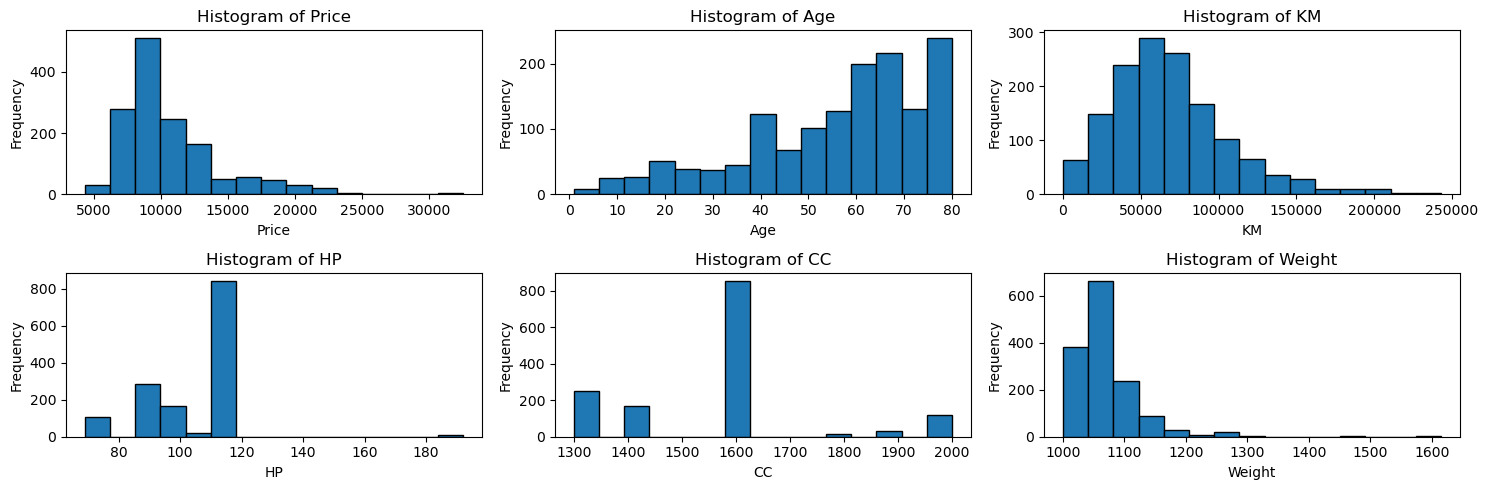

In [28]:
plot_data(numeric_columns,'Histogram',2,3,15,5)

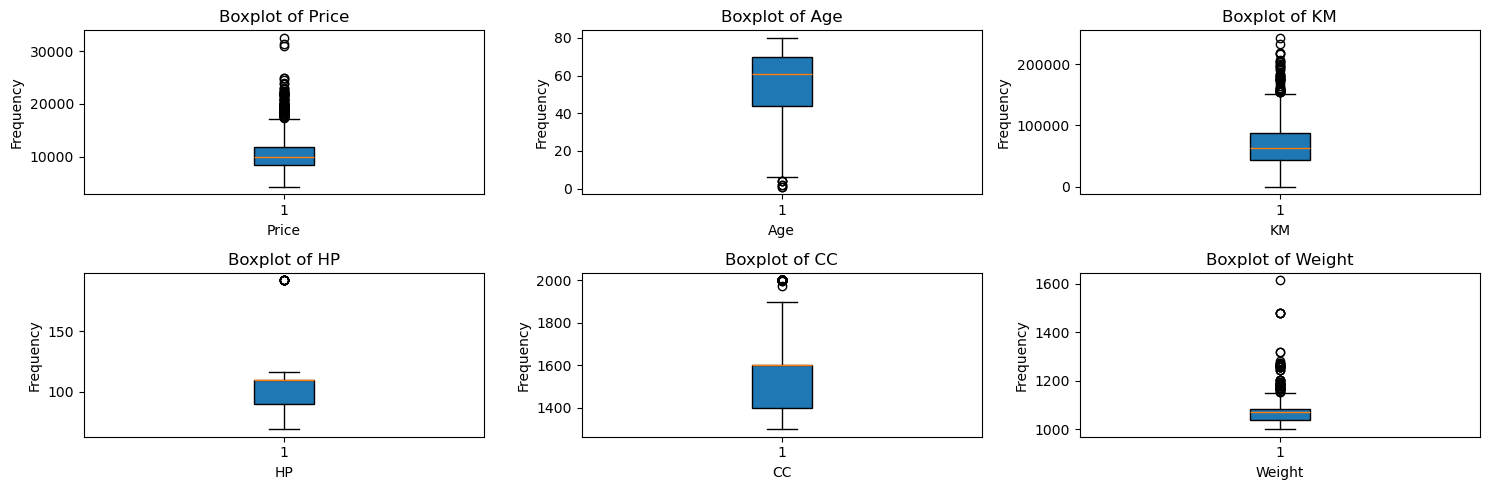

In [29]:
plot_data(numeric_columns,'Boxplot',2,3,15,5)

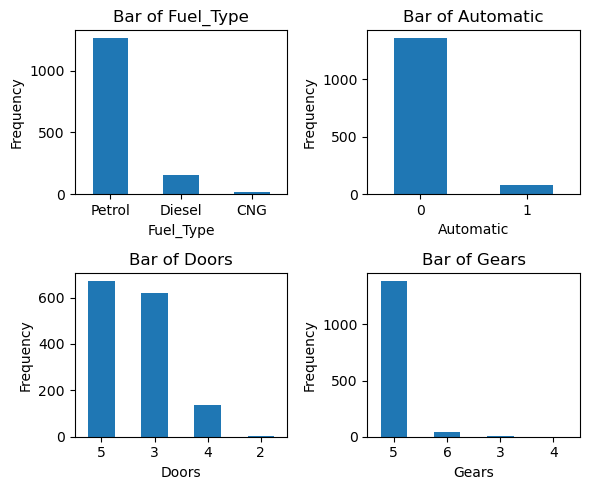

In [30]:
plot_data(cat_columns,'Bar',2,2,6,5)

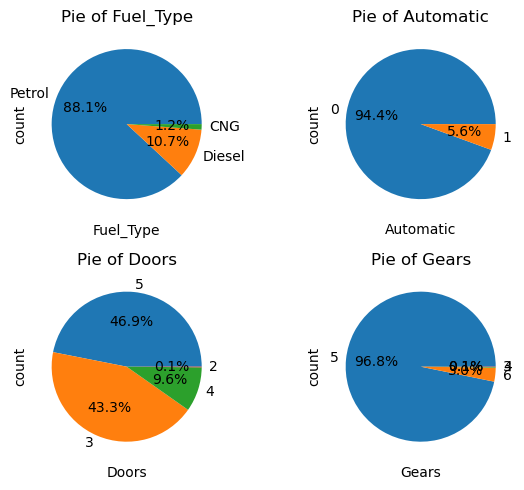

In [31]:
plot_data(cat_columns,'Pie',2,2,6,5)

* 88% of cars belongs to petrol class
* 95% of cars belongs to Manual
* 97% of cars belongs to 5 Gears

In [32]:
df.describe()

,Price,Age,KM,HP,CC,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,101.491986,1566.526132,1072.287108
std,3608.732978,18.563312,37491.094553,14.981408,186.897718,52.251882
min,4350.000000,1.000000,1.000000,69.000000,1300.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,1400.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,1600.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,1600.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,2000.000000,1615.000000


In [33]:
numeric_columns.corr()

,Price,Age,KM,HP,CC,Weight
Price,1.000000,-0.876273,-0.569420,0.314134,0.159897,0.575869
Age,-0.876273,1.000000,0.504575,-0.155293,-0.129564,-0.466484
KM,-0.569420,0.504575,1.000000,-0.332904,0.305331,-0.023969
HP,0.314134,-0.155293,-0.332904,1.000000,0.049430,0.087143
CC,0.159897,-0.129564,0.305331,0.049430,1.000000,0.650098
Weight,0.575869,-0.466484,-0.023969,0.087143,0.650098,1.000000


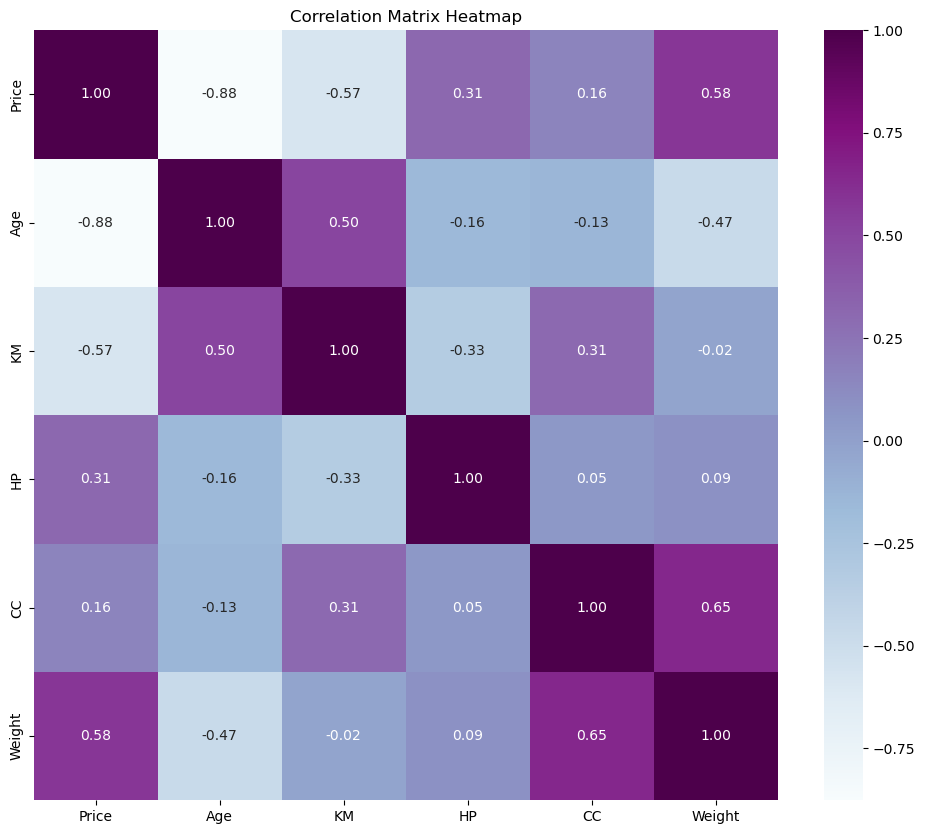

In [34]:
# Calculate the correlation matrix
correlation_matrix = numeric_columns.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='BuPu', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

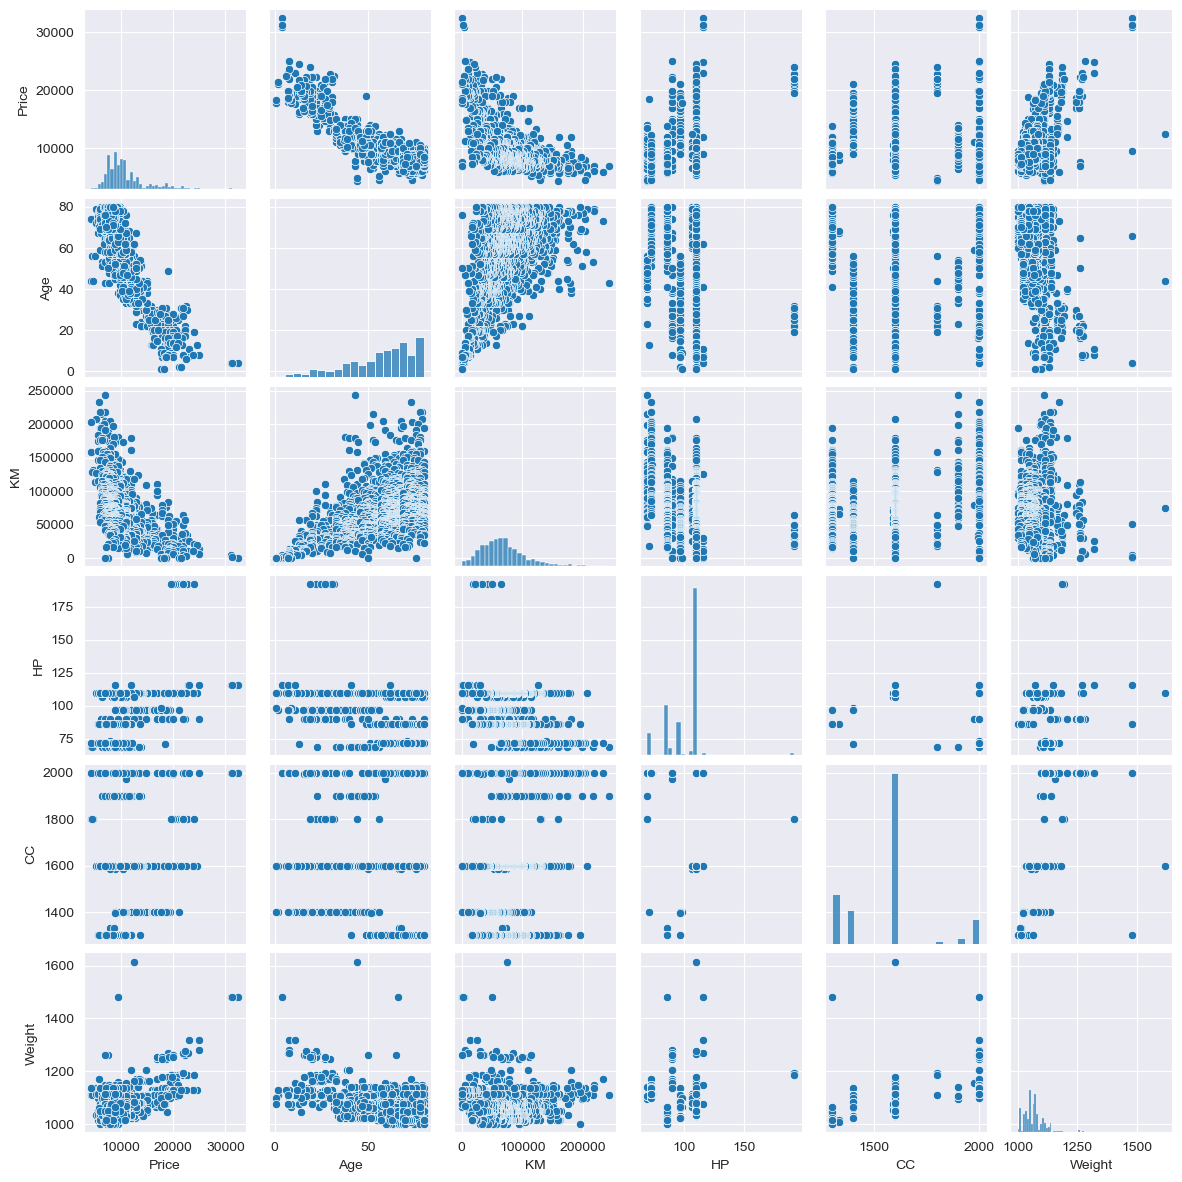

In [35]:

sns.set_style(style='darkgrid')
sns.pairplot(df, vars = list(numeric_columns.columns),height=2, aspect=1)

In [36]:
# Create a user defined funtion to display correlation between Numetic columns

def analyze_correlations(df: pd.DataFrame, threshold: float = 0.05):
    # Select only numeric columns for correlation calculation
    numeric_df = df.select_dtypes(include=['number'])
    
    if numeric_df.empty:
        print("No numeric columns found in the DataFrame.")
        return

    # Calculate the correlation matrix
    correlation_matrix = numeric_df.corr(method='pearson')
    
    print(f"--- Correlation Analysis (Threshold = +/-{threshold}) ---")

    # Iterate through the correlation matrix
    # Use nested loops to compare each pair of unique columns once
    for col1 in correlation_matrix.columns:
        for col2 in correlation_matrix.columns:
            # Ensure we only check each unique pair once (and not a column with itself)
            if col1 != col2 and col1 < col2:
                correlation_value = correlation_matrix.loc[col1, col2]
                
                # Determine the type of correlation based on the value and threshold
                if abs(correlation_value) < threshold:
                    correlation_type = "No correlation"
                elif correlation_value > 0:
                    correlation_type = "Positive correlation"
                else:
                    correlation_type = "Negative correlation"
                
                # Print the result
                print(f"'{col1}' and '{col2}': {correlation_type} (Value: {correlation_value:.4f})")



In [37]:
analyze_correlations(df)

--- Correlation Analysis (Threshold = +/-0.05) ---
'Price' and 'Weight': Positive correlation (Value: 0.5759)
'Age' and 'Price': Negative correlation (Value: -0.8763)
'Age' and 'KM': Positive correlation (Value: 0.5046)
'Age' and 'HP': Negative correlation (Value: -0.1553)
'Age' and 'CC': Negative correlation (Value: -0.1296)
'Age' and 'Weight': Negative correlation (Value: -0.4665)
'KM' and 'Price': Negative correlation (Value: -0.5694)
'KM' and 'Weight': No correlation (Value: -0.0240)
'HP' and 'Price': Positive correlation (Value: 0.3141)
'HP' and 'KM': Negative correlation (Value: -0.3329)
'HP' and 'Weight': Positive correlation (Value: 0.0871)
'CC' and 'Price': Positive correlation (Value: 0.1599)
'CC' and 'KM': Positive correlation (Value: 0.3053)
'CC' and 'HP': No correlation (Value: 0.0494)
'CC' and 'Weight': Positive correlation (Value: 0.6501)


In [38]:
import pandas as pd
import numpy as np

def analyze_skewness(df):
    print("--- Skewness Analysis ---")
    
    # Iterate over each column in the DataFrame
    for col_name in df.columns:
        # Check if the column is numerical
        if pd.api.types.is_numeric_dtype(df[col_name]):
            column = df[col_name].dropna() # Remove NaNs for calculation
            
            if len(column) < 3: # Need at least 3 values to calculate skewness
                print(f"Column '{col_name}': Not enough data to analyze skewness.")
                continue

            # Calculate the third moment of deviation (numerator)
            mean = np.mean(column)
            std = np.std(column, ddof=0) # use population std deviation for this formula
            n = len(column)
            
            if std == 0:
                print(f"Column '{col_name}': All values are the same (no variance).")
                continue

            # Calculate skewness using the adjusted formula (avoids scipy)
            # This is the Fisher-Pearson coefficient of skewness
            skewness_coeff = (1 / n) * np.sum(((column - mean) / std) ** 3)
            
            # Classify the skewness based on the coefficient
            if -0.5 <= skewness_coeff <= 0.5:
                classification = "Symmetric"
            elif skewness_coeff < -0.5:
                classification = "Left Skewed" # Skewed left (negative)
            else:
                classification = "Right Skewed" # Skewed right (positive)
            
            print(f"Column '{col_name}': {classification} (Coefficient: {skewness_coeff:.4f})")
        else:
            print(f"Column '{col_name}': Non-numerical data (cannot analyze skewness).")




In [39]:
analyze_skewness(df)

--- Skewness Analysis ---
Column 'Price': Right Skewed (Coefficient: 1.6948)
Column 'Age': Left Skewed (Coefficient: -0.8247)
Column 'KM': Right Skewed (Coefficient: 1.0160)
Column 'Fuel_Type': Non-numerical data (cannot analyze skewness).
Column 'HP': Right Skewed (Coefficient: 0.9568)
Column 'Automatic': Non-numerical data (cannot analyze skewness).
Column 'CC': Right Skewed (Coefficient: 0.6060)
Column 'Doors': Non-numerical data (cannot analyze skewness).
Column 'Gears': Non-numerical data (cannot analyze skewness).
Column 'Weight': Right Skewed (Coefficient: 3.1133)


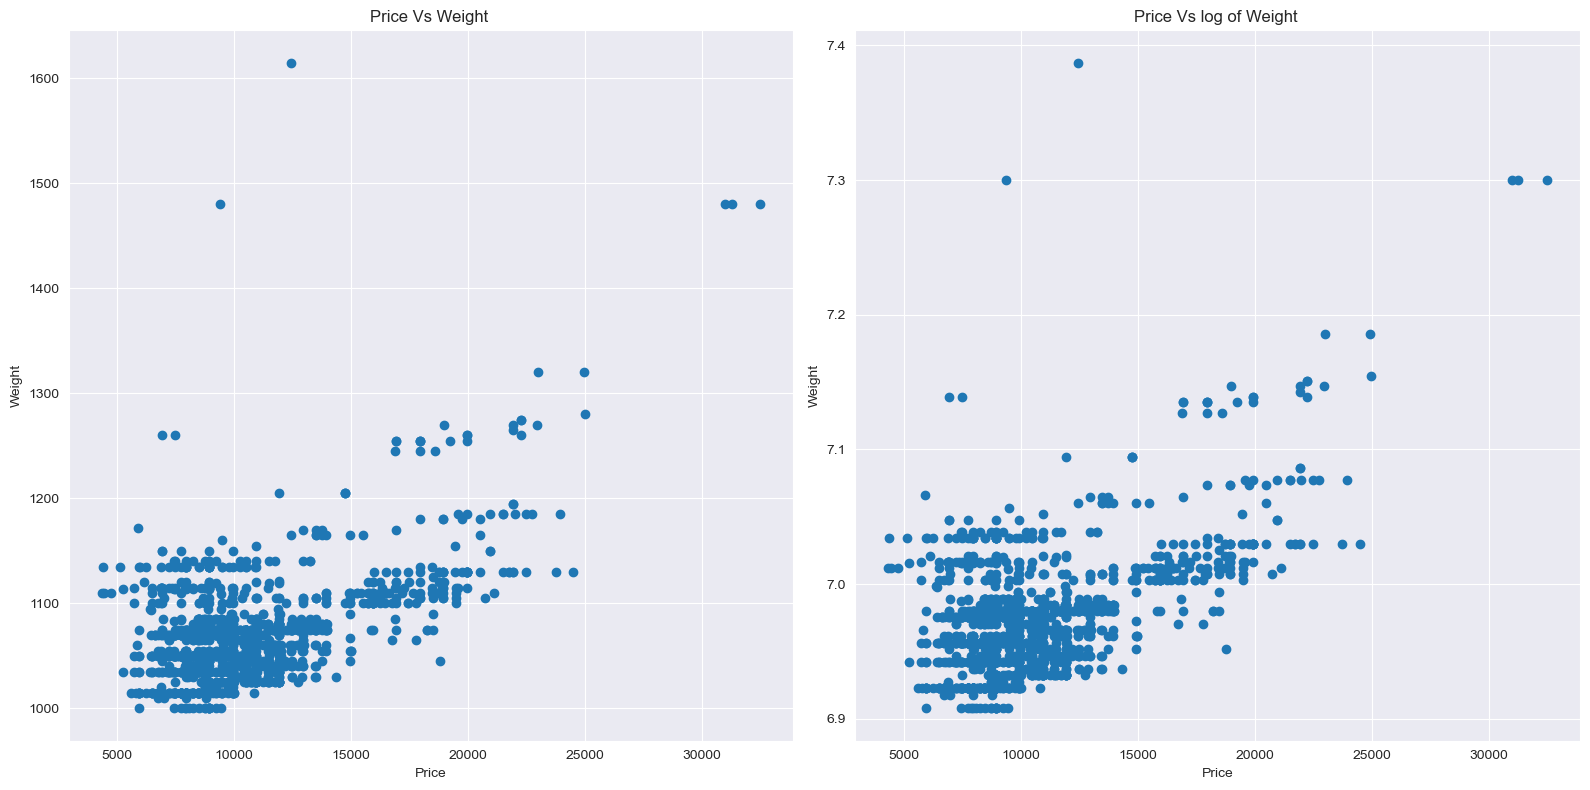

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16,8))
axes = axes.flatten()
axes[0].scatter(df['Price'], df['Weight'])
axes[0].set_title(f'Price Vs Weight ')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Weight')

axes[1].scatter(df['Price'], np.log(df['Weight']))
axes[1].set_title(f'Price Vs log of Weight ')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Weight')


plt.tight_layout()
plt.show()

#### Pre-process the data to apply the MLR

In [41]:
df.columns

Index(['Price', 'Age', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'CC', 'Doors',
       'Gears', 'Weight'],
      dtype='object')

In [42]:
df = df.reindex(columns=['Fuel_Type','Doors', 'Gears','Age', 'KM',  'HP', 'Automatic', 'CC',  'Weight','Price'])

In [43]:
df.columns


Index(['Fuel_Type', 'Doors', 'Gears', 'Age', 'KM', 'HP', 'Automatic', 'CC',
       'Weight', 'Price'],
      dtype='object')

In [44]:
df.head()

,Fuel_Type,Doors,Gears,Age,KM,HP,Automatic,CC,Weight,Price
0,Diesel,3,5,23,46986,90,0,2000,1165,13500
1,Diesel,3,5,23,72937,90,0,2000,1165,13750
2,Diesel,3,5,24,41711,90,0,2000,1165,13950
3,Diesel,3,5,26,48000,90,0,2000,1165,14950
4,Diesel,3,5,30,38500,90,0,2000,1170,13750


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Fuel_Type  1435 non-null   object
 1   Doors      1435 non-null   object
 2   Gears      1435 non-null   object
 3   Age        1435 non-null   int64 
 4   KM         1435 non-null   int64 
 5   HP         1435 non-null   int64 
 6   Automatic  1435 non-null   object
 7   CC         1435 non-null   int64 
 8   Weight     1435 non-null   int64 
 9   Price      1435 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 123.3+ KB


#### Encoding Categorical Data

In [46]:

from sklearn.preprocessing import OneHotEncoder
categorical_columns = ['Fuel_Type','Doors','Gears']
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([df, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(f"Encoded Employee data : \n{df_encoded}")

Encoded Employee data : 
       Age       KM     HP Automatic      CC  Weight    Price  Fuel_Type_CNG  \
0     23.0  46986.0   90.0         0  2000.0  1165.0  13500.0            0.0   
1     23.0  72937.0   90.0         0  2000.0  1165.0  13750.0            0.0   
2     24.0  41711.0   90.0         0  2000.0  1165.0  13950.0            0.0   
3     26.0  48000.0   90.0         0  2000.0  1165.0  14950.0            0.0   
4     30.0  38500.0   90.0         0  2000.0  1170.0  13750.0            0.0   
...    ...      ...    ...       ...     ...     ...      ...            ...   
1432  72.0  19000.0   86.0         0  1300.0  1015.0  10845.0            0.0   
1433  71.0  17016.0   86.0         0  1300.0  1015.0   8500.0            0.0   
1434  70.0  16916.0   86.0         0  1300.0  1015.0   7250.0            0.0   
1435  76.0      1.0  110.0         0  1600.0  1114.0   6950.0            NaN   
113    NaN      NaN    NaN       NaN     NaN     NaN      NaN            0.0   

      Fuel_Typ

In [47]:
df_encoded[df_encoded.isnull().any(axis=1)]

,Age,KM,HP,Automatic,CC,Weight,Price,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Doors_2,Doors_3,Doors_4,Doors_5,Gears_3,Gears_4,Gears_5,Gears_6
1435,76.0,1.0,110.0,0,1600.0,1114.0,6950.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [48]:
df_encoded =df_encoded.dropna()

In [49]:
df_encoded[df_encoded.isnull().any(axis=1)]

,Age,KM,HP,Automatic,CC,Weight,Price,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Doors_2,Doors_3,Doors_4,Doors_5,Gears_3,Gears_4,Gears_5,Gears_6


#### 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [50]:
len(df_encoded.columns)

18

In [51]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Price', axis=1) # Features
y = df_encoded['Price'] # Target

# Perform the split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (1147, 17)
Testing shape: (287, 17)


In [52]:
df_encoded[df_encoded.isnull().any(axis=1)]

,Age,KM,HP,Automatic,CC,Weight,Price,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Doors_2,Doors_3,Doors_4,Doors_5,Gears_3,Gears_4,Gears_5,Gears_6


In [53]:
df[df.isnull().any(axis=1)]


,Fuel_Type,Doors,Gears,Age,KM,HP,Automatic,CC,Weight,Price


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Fuel_Type  1435 non-null   object
 1   Doors      1435 non-null   object
 2   Gears      1435 non-null   object
 3   Age        1435 non-null   int64 
 4   KM         1435 non-null   int64 
 5   HP         1435 non-null   int64 
 6   Automatic  1435 non-null   object
 7   CC         1435 non-null   int64 
 8   Weight     1435 non-null   int64 
 9   Price      1435 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 155.6+ KB


#### 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. 
Build a minimum of 3 different models.

In [55]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)



LinearRegression()

In [56]:
y_pred = regressor.predict(X_test)

In [57]:
y_pred

array([14338.67850343, 10427.88022488,  9096.27771537, 11727.00059649,
        9486.0683872 , 11638.09263565, 12246.06588302, 15247.86978862,
        9234.27456428,  9564.87434608, 10325.87529209,  6917.24346664,
        8704.17802564, 17637.18429601, 11283.7635535 , 11270.45032017,
        6571.917968  , 11873.74362819,  8046.48498193,  9023.4950741 ,
       13639.79214315, 12912.02102335,  5913.45997116, 26276.33816423,
        7733.89570245, 15927.5188104 ,  8331.91126562, 10118.33245345,
        9161.85217512,  9806.10425953, 11807.27576277, 16021.47911981,
        6503.22013268,  8898.77718344,  7851.44815752, 11153.07801519,
       13017.69947306, 11814.59905792,  8962.67052439, 18342.61348584,
        9662.08416879,  7607.93410769,  9622.62233769,  9790.00362155,
        4930.55020406,  9841.49188906,  8688.48227005, 11138.93155107,
        7647.51666112,  8835.66993598, 10369.35294453, 16193.00119851,
        6612.98754535, 10099.78335279,  9939.68014044, 16633.28855163,
      

In [58]:
regressor.coef_

array([-1.20755601e+02, -1.57151298e-02,  3.30172932e+01,  2.78862617e+01,
       -2.23743197e+00,  2.57540932e+01, -2.46727761e+02,  9.37810189e+01,
        1.52946742e+02,  6.68018957e+02, -2.92565046e+02, -9.98699185e+01,
       -2.75583993e+02, -5.77458194e+02,  0.00000000e+00,  2.77613598e+02,
        2.99844596e+02])

In [59]:
regressor.intercept_

np.float64(-9044.640796344871)

Evaluating the model's performance

In [60]:
#Evaluating model performance
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print('R-square',r2)


n = len(X_test)
p = X_test.shape[1]
Adj_r2 = 1-(1-r2)*(n-1)/(n-p-1)
print('Adjusted R2',Adj_r2)

R-square 0.8366846098376387
Adjusted R2 0.8263635628757051


Our model is a good fit as the falls within the 0.8 adn 0.9.

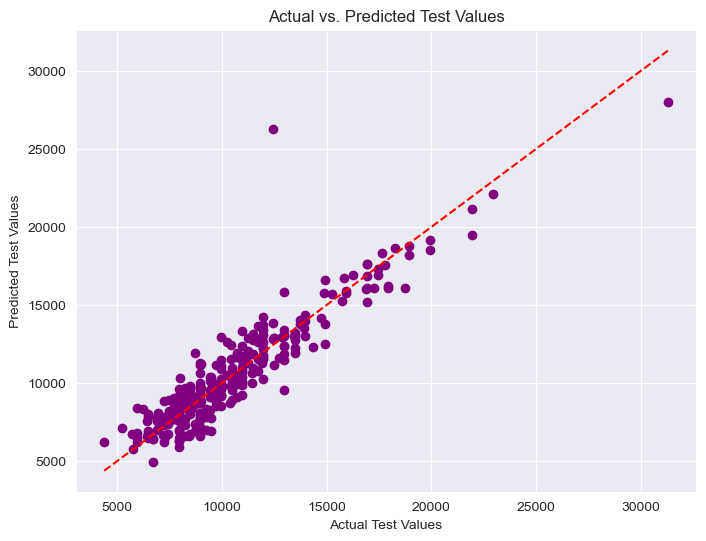

In [61]:
#Plotting our predictions againt the actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color = 'purple')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Ideal line
plt.xlabel('Actual Test Values')
plt.ylabel('Predicted Test Values')
plt.title('Actual vs. Predicted Test Values')
plt.show()

In [62]:
df_encoded
df['Doors'].unique()

array([3, 5, 4, 2], dtype=object)

#### Model 1

In [63]:
df_model =df.copy()

In [64]:
df_model

,Fuel_Type,Doors,Gears,Age,KM,HP,Automatic,CC,Weight,Price
0,Diesel,3,5,23,46986,90,0,2000,1165,13500
1,Diesel,3,5,23,72937,90,0,2000,1165,13750
2,Diesel,3,5,24,41711,90,0,2000,1165,13950
3,Diesel,3,5,26,48000,90,0,2000,1165,14950
4,Diesel,3,5,30,38500,90,0,2000,1170,13750
...,...,...,...,...,...,...,...,...,...,...
1431,Petrol,3,5,69,20544,86,0,1300,1025,7500
1432,Petrol,3,5,72,19000,86,0,1300,1015,10845
1433,Petrol,3,5,71,17016,86,0,1300,1015,8500
1434,Petrol,3,5,70,16916,86,0,1300,1015,7250


In [65]:

# Create dummy variables for 'Fuel_Type', 'Doors', and 'Gears'
df_model = pd.get_dummies(df_model, columns=['Fuel_Type', 'Doors', 'Gears'], drop_first=True)
# Convert True to 1 and False to 0
df_model = df_model.replace({True: 1, False: 0})

# Print the modified DataFrame
df_model.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19052\82014404.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model = df_model.replace({True: 1, False: 0})


,Age,KM,HP,Automatic,CC,Weight,Price,Fuel_Type_Diesel,Fuel_Type_Petrol,Doors_3,Doors_4,Doors_5,Gears_4,Gears_5,Gears_6
0,23,46986,90,0,2000,1165,13500,1,0,1,0,0,0,1,0
1,23,72937,90,0,2000,1165,13750,1,0,1,0,0,0,1,0
2,24,41711,90,0,2000,1165,13950,1,0,1,0,0,0,1,0
3,26,48000,90,0,2000,1165,14950,1,0,1,0,0,0,1,0
4,30,38500,90,0,2000,1170,13750,1,0,1,0,0,0,1,0


In [66]:
df_model = df_model.astype(np.float64)

In [67]:
# Separate features (X) and target variable (y)
X = df_model.drop('Price', axis=1)
y = df_model['Price']

from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [68]:
import statsmodels.api as sm
#Exogenous - independent features, and Endogenous - dependent variable
model_1 = sm.OLS(endog = y_train, exog = X_train.assign(intercept=1)).fit()
#Printing summary
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     510.3
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:50:04   Log-Likelihood:                -9896.7
No. Observations:                1148   AIC:                         1.982e+04
Df Residuals:                    1133   BIC:                         1.990e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Age               -123.1079      2.982  

This output is a summary of an Ordinary Least Squares (OLS) regression 
Key Metrics
R-squared (0.863)
Adj. R-squared (0.861):

R-square 0.8938579212015434
Adjusted R2 0.8883947259692699


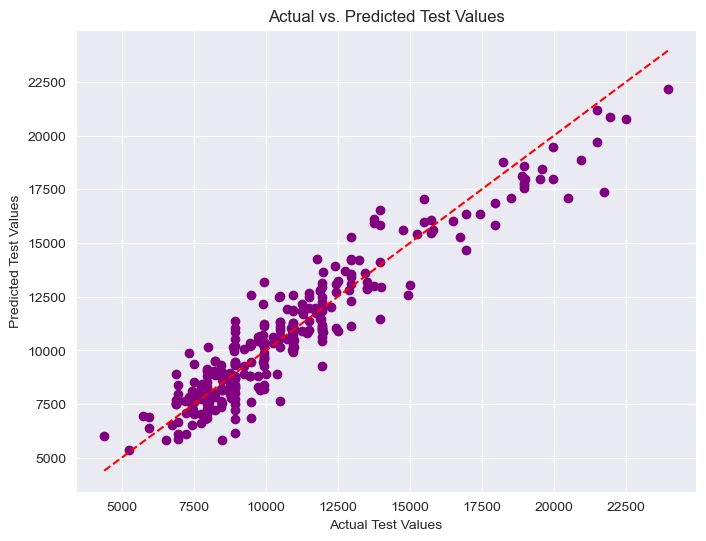

In [69]:
# Get the predicted values
y_pred = model_1.predict(X_test.assign(intercept=1))

#Evaluating model performance
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print('R-square',r2)


n = len(X_test)
p = X_test.shape[1]
Adj_r2 = 1-(1-r2)*(n-1)/(n-p-1)
print('Adjusted R2',Adj_r2)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='purple')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Test Values')
plt.ylabel('Predicted Test Values')
plt.title('Actual vs. Predicted Test Values')
plt.show()

The R-sq value is in the 0.8 to 0.9 range meaning the regression line is a good fit.\
This can be considered a good MLR (Multiple Linear Regression) model, as the predicted values are very close to the actual values,\
and the overall fit appears strong.

#### Model 2

Features Selection

##### Top Python OLS Feature Selection Techniques
**P-Value Selection (Statsmodels):** Fit an OLS model and remove features with high p-values >0.05, indicating they are not statistically significant.\
**Recursive Feature Elimination (RFE) (Scikit-learn):**\Recursively trains the model and removes the weakest features based on coef_ or feature_importances_.\
**L1 Regularization (Lasso Regression):** Adds a penalty to the OLS cost function, shrinking coefficients of irrelevant features to zero, effectively selecting features.\
**Univariate Selection (SelectKBest):** Uses statistical tests (e.g., F-test) to select the top \(K\) features that have the strongest relationship with the target variable.\
**Variance Thresholding:** Removes features with low variance (values that do not change much), which are typically poor predictors

Dropping the Door Feature:

In [70]:
import statsmodels.api as sm
X_train.drop(['Doors_3', 'Doors_4', 'Doors_5','Automatic'], axis=1, inplace = True)
model_2 = sm.OLS(endog = y_train, exog = X_train.assign(intercept=1)).fit()
#Printing summary
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     712.2
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:50:06   Log-Likelihood:                -9900.0
No. Observations:                1148   AIC:                         1.982e+04
Df Residuals:                    1137   BIC:                         1.988e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Age               -122.6734      2.963  

In [71]:
X_train.drop(['Gears_4','Gears_5'] , axis=1, inplace = True)
model_2 = sm.OLS(endog = y_train, exog = X_train.assign(intercept=1)).fit()
#Printing summary
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     888.4
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:50:06   Log-Likelihood:                -9901.9
No. Observations:                1148   AIC:                         1.982e+04
Df Residuals:                    1139   BIC:                         1.987e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Age               -122.7896      2.955  

In [72]:
X_train.drop('Gears_6', axis=1, inplace = True)
model_2 = sm.OLS(endog = y_train, exog = X_train.assign(intercept=1)).fit()
#Printing summary
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     1013.
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:50:06   Log-Likelihood:                -9903.3
No. Observations:                1148   AIC:                         1.982e+04
Df Residuals:                    1140   BIC:                         1.986e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Age               -122.7406      2.957  

### Evaluating Performance

In [73]:
import statsmodels.api as sm
main_model = sm.OLS(endog = y_train, exog = X_train.assign(intercept=1)).fit()
main_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     1013.
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:50:06   Log-Likelihood:                -9903.3
No. Observations:                1148   AIC:                         1.982e+04
Df Residuals:                    1140   BIC:                         1.986e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Age               -122.7406      2.957    -41.511      0.000    -128.542    -116.939
KM                  -0.0170      0.002    -11.253      0.000      -0.020      -0.014
HP                  59.0061      6.831      8.638      0.000      45.604      72.409
CC                  -3.8865      0.637     -6.098      0.000      -5.137      -2.636
Weight              18.9491      1.214     15.615      0.000      16.568      21.330
Fuel_Type_Diesel  3454.1523    613.031      5.635      0.000    2251.356    4656.948
Fuel_Type_Petrol  1127.9311    404.365      2.789      0.005     334.547    1921.315
intercept        -2834.3146   1393.506     -2.034      0.042   -5568.439    -100.191
==============================================================================
Omnibus:                      226.356   Durbin-Watson:                   1.885
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2169.888
Skew:                          -0.613   Prob(JB):                         0.00
Kurtosis:                       9.623   Cond. No.                     2.77e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.77e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [75]:
print(X_train.shape) 
print(X_test.shape)


(1148, 7)
(287, 14)


In [83]:
X_test.drop(['Doors_3', 'Doors_4', 'Doors_5','Automatic','Gears_4','Gears_5','Gears_6'], axis=1, inplace = True)


In [84]:
print(X_train.shape) 
print(X_test.shape)

(1148, 7)
(287, 7)


In [85]:
y_pred = main_model.predict(X_test.assign(intercept=1))
output = pd.DataFrame({'Predicted': y_pred, 'Actual': y_test})
output

,Predicted,Actual
652,8761.134072,9450.0
412,11346.440443,8950.0
343,13134.861738,11950.0
1298,7676.189598,7500.0
484,10306.080178,9500.0
...,...,...
1047,5323.163250,5250.0
1014,10155.334842,10450.0
521,11006.091866,11950.0
995,9387.911820,9950.0


In [86]:
r2 = r2_score(y_test, y_pred)
print('R-square', r2)
vif = 1/(1-r2)
print('VIF',vif)


R-square 0.8911438078138308
VIF 9.186431932965005


Lasso Regression

In [87]:
from sklearn.linear_model import Lasso
lasso_regressor = Lasso()
lasso_regressor.fit(X_train, y_train)

# Predicting on test set
y_pred = lasso_regressor.predict(X_test)

In [88]:
y_pred

array([ 8954.23640768, 11342.7649478 , 13131.06419042,  7676.30917379,
       10295.3267218 ,  8965.46703398,  5923.55699658, 16119.23926086,
       11518.26725932, 10759.60068105,  6053.15357544, 10269.93271497,
       11246.47710322,  9760.3278194 , 11398.76813631, 16019.77225641,
       11386.92850099,  9803.88184724, 12431.89734581,  7011.91906273,
       10048.28901423,  6144.2167424 , 11279.37095133, 11343.91544279,
       18605.18636832,  9559.57376266, 13212.37134524,  5588.56630415,
        8710.34883011,  7846.88419995, 11175.99621596,  9884.49224239,
       15972.97589191,  7315.63616679, 11517.58559148, 13695.08028008,
        9239.1555983 , 12867.70823446,  7918.2060745 , 10523.45830395,
        7507.88901066,  5871.11228851, 10742.15740245, 16748.33981338,
       10222.57232947,  7074.41959905,  9057.06271527,  7719.93077771,
        8783.81192535,  7282.97448702, 17364.38847704,  7792.99984946,
        7924.9354959 , 10235.7148869 ,  6690.04422087, 16913.58930106,
      

In [89]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print('R-squared:', r2)

vif = 1/(1-r2)
print('VIF',vif)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mse)

R-squared: 0.8912829469248593
VIF 9.198188984287881
Mean Squared Error: 1351427.1188009419


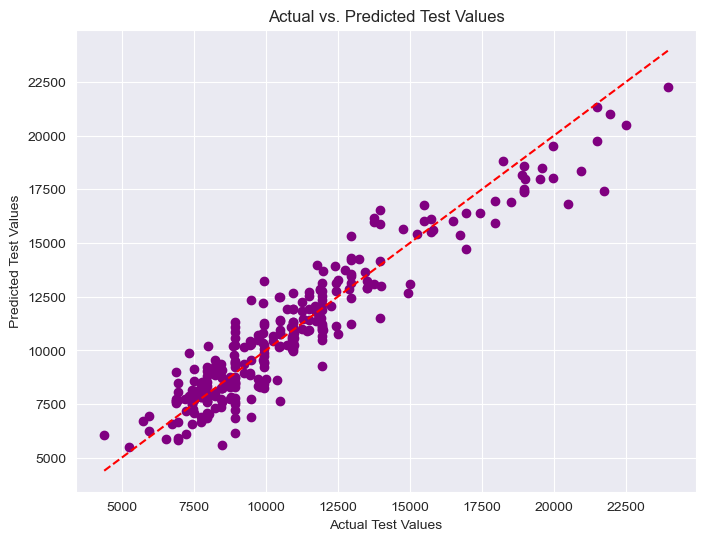

In [90]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color = 'purple')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Ideal line
plt.xlabel('Actual Test Values')
plt.ylabel('Predicted Test Values')
plt.title('Actual vs. Predicted Test Values')
plt.show()

#### Conclusion
We have developed a strong regression model by performing backward elimination to remove statistically insignificant variables.\
After evaluating the model on the test set, we obtained an R² value of 0.89, indicating a good fit. \
The Variance Inflation Factor (VIF) values is 9.198188984287881 

## Interview Questions:

**Normalization and Standardization are**
two essential data preprocessing techniques in machine learning and data science used to scale numerical data. They transform features into a similar scale to prevent models from being dominated by variables with larger ranges, improving model accuracy and convergence speed

Imagine a dataset with "Age" (20-60) and "Salary" (30k-100k). , In this Age is in 2 digits and Salary is in 5 digits

### 1. Normalization (Min-Max Scaling)
**Definition:** Normalization scales the numerical data to a fixed range, usually 0 to 1 or -1 to 1. It does not assume any specific distribution (like normal distribution) of the data

**Formula:** $x' = \frac{x - \text{min}(x)}{\text{max}(x) - \text{min}(x)}$

*   **$x$**: Original value
*   **$x'$**: Normalized value (0 to 1)
*   **$\text{min}(x)$**: Minimum value in the dataset
*   **$\text{max}(x)$**: Maximum value in the dataset

**Step-by-Step Example (Normalization)**\
Imagine a dataset with "Age" (20-60) and "Salary" (30k-100k).\
Original Data: Salary = 50,000, Min = 30,000, Max = 100,000.\
Difference: $x - \text{min}(x)$=50,000-30,000=20,000.\
Range:  $\text{max}(x) - \text{min}(x)$=100,000-30,000=70,000.\
**Normalize**: \(20,000/70,000=\mathbf{0.285}\)\
All salaries will now be between 0 and 1

#### 2. Standardization (Z-Score Normalization)
**Definition:** Standardization transforms data to have a mean of 0 and a standard deviation of 1.\
It transforms the data into a standard normal distribution (Gaussian).\
**Formula:** $Z=\frac{X-\mu }{\sigma }$ (where $\mu$ is mean, $\sigma$ is standard deviation)\
**Use Case:** Best when data follows a Gaussian distribution or when the algorithm assumes it (e.g., Linear Regression, Logistic Regression, Support Vector Machines). 

**Step-by-Step Example (Standardization)**\
Using the same Salary data $X$ where $\mu$ =60k, $\sigma$ =10k, \(X=50,000\).\
**Center Data:** $X-\mu$ =50,000-60,000=-10,000\)\
**Scale Data:** -10,000/10,000=-1.0\
The value -1.0 means this salary is 1 standard deviation below the mean

#### 3. Key Differences Table
|Feature |Normalization|Standardization|
|---------|----------|-------------|
|Range |Typically 0 to 1|No strict boundary (unbounded)|
|Formula|$(X-Xmin)/(Xmax-Xmin)$|$(X-Mean)/StdDev$|
|Distribution|No assumption|Assumes Gaussian (Normal)|
|Outliers|Highly sensitive|Less sensitive (more robust)|
|Best| ForKNN, Neural Networks, Image Pixel data|Linear Regression, SVM, PCA|

#### 4. How it is Helpful 

**Faster Convergence:** Algorithms like Gradient Descent converge much faster when features are on a similar scale.\
**Prevents Dominance:** Prevents features with large magnitudes (e.g., Income) from dominating features with small magnitudes (e.g., Age) in distance-based algorithms.\
**Accuracy:** Essential for algorithms that rely on distance calculations (K-NN) or assume normally distributed data (SVM)

#### 2.What techniques can be used to address multicollinearity in multiple linear regression?


**Multicollinearity** in multiple linear regression occurs when **independent variables are highly correlated**, causing unstable coefficient estimates.
Key solutions include removing redundant variables, combining variables (feature engineering), using dimensionality reduction like Principal Component Analysis (PCA), or applying regularization techniques like Ridge or Lasso regression

##### Step-by-Step Techniques to Address Multicollinearity
1. Identify Multicollinearity (Diagnostic Step
   * Action: Calculate the Variance Inflation Factor (VIF) for each predictor. A VIF > 5-10 indicates high multicollinearity.
   * Visualization: Use a correlation matrix heatmap (Seaborn in Python) to visualize Pearson correlation coefficients between variables.
   * 
2. Remove One of the Highly Correlated Variables
   * Action: If two variables are highly correlated, drop the one that is less relevant to the target or has a higher VIF.
   * Example: In a house price model, if Number of Rooms and Total Square Footage are highly correlated $(r>0.9)$, remove Number of Rooms and keep Square Footage.
3. Combine Correlated Variables
   * Action: Create a new feature representing the combination (e.g., average, sum) of the correlated variables.
   * Example: If you have 10 correlated environmental factors, PCA reduces them to 2 or 3 uncorrelated principal components while retaining most information
4. Use Regularization (Ridge or Lasso Regression)
   * Action: Apply Ridge $(L_{2})$ or Lasso $(L_{1})$ regression, which adds a penalty term to the regression formula, shrinking coefficients and reducing the impact of collinearity.
    * **Ridge:** Keeps all variables but shrinks coefficients.
    * **Lasso:** Can reduce some coefficients to zero, performing feature selection.
5. Principal Component Analysis (PCA)
    * Action: Transform the original correlated predictors into a new set of uncorrelated components, then run regression on these components.
    * Example: If you have 10 correlated environmental factors, PCA reduces them to 2 or 3 uncorrelated principal components while retaining most information.
6. Increase Sample Size (Data Collection)
    * Action: More data points can sometimes break the perfect linear relationship between variables, stabilizing the estimate